In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold
from torch.utils.data import DataLoader
from scipy import stats

import matplotlib.pyplot as plt

<h1 style="text-align:center; color:royalblue">Data Preparation</h1>

In [4]:
mnist = fetch_openml('mnist_784',version=1, as_frame=False)
X,y = mnist['data'], mnist['target']
X[:10],y[:10]

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10, 784)),
 array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object))

In [86]:
np.std(X)

np.float64(78.65437362689416)

In [87]:
np.mean(X)

np.float64(33.385964741253645)

In [5]:
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

In [89]:
np.std(X)

np.float32(0.30844852)

In [90]:
np.mean(X)

np.float32(0.13092536)

In [6]:
X_trainval, X_test, y_trainval,y_test = train_test_split(X,y,test_size=10000, random_state=42, stratify=y)

---

<h1 style="text-align:center; color:royalblue">Model Creation</h1>

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.input = nn.Linear(784,2*784)
        self.hidden1 = nn.Linear(2*784,2*784)
        self.hidden2 = nn.Linear(2*784,2*784)
        self.output = nn.Linear(2*784,10)

        self.softmax = nn.Softmax()
        self.relu = nn.ReLU()

    def forward(self,X):
        X = self.flatten(X)
        X = self.relu(self.input(X))
        X = self.relu(self.hidden1(X))
        X = self.relu(self.hidden2(X))
        X = self.output(X)

        X = self.softmax(X)

        return X



In [93]:
model = MLP().to('cuda')

In [94]:
optimizer = optim.SGD(params=model.parameters(),lr=0.01)
loss_fn = nn.CrossEntropyLoss()

In [95]:
kFold = KFold(n_splits=5, shuffle=True)

---

<h1 style="text-align:center; color:royalblue">Training</h1>

In [96]:
best_val_loss = float('inf')

N_EPOCHS = 100

In [97]:
for fold, (train_idx, val_idx) in enumerate(kFold.split(X_trainval)):
    print(f"Fold {fold}")
    train_losses = []
    val_losses = []

    X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    train_loader = DataLoader(list(zip(X_train,y_train)), batch_size=1024, shuffle=True)
    val_loader = DataLoader(list(zip(X_val,y_val)), batch_size=1024, shuffle=False)

    for epoch in range(N_EPOCHS):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            
            optimizer.zero_grad()
            y_pred = model(X_batch)

            loss = loss_fn(y_pred, y_batch)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        with torch.inference_mode():
            model.eval()
            val_loss = 0.0
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
                y_pred = model(X_batch)
                val_loss += loss_fn(y_pred, y_batch).item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            dct = {
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses
            }

            torch.save(dct, f'best_mlp_{fold}.pth')

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}")

Fold 0


c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0, Train Loss: 2.3024754372048886, Val Loss: 2.302429676055908
Epoch 10, Train Loss: 2.301599898236863, Val Loss: 2.3015654484430947
Epoch 20, Train Loss: 2.3006346073556454, Val Loss: 2.3006101648012796
Epoch 30, Train Loss: 2.29950391485336, Val Loss: 2.299487312634786
Epoch 40, Train Loss: 2.2980963625806443, Val Loss: 2.298083742459615
Epoch 50, Train Loss: 2.296225588372413, Val Loss: 2.296211858590444
Epoch 60, Train Loss: 2.2935198317182826, Val Loss: 2.2934905886650085
Epoch 70, Train Loss: 2.288962678706392, Val Loss: 2.2888731956481934
Epoch 80, Train Loss: 2.277530020855843, Val Loss: 2.2769445180892944
Epoch 90, Train Loss: 2.2441803800298814, Val Loss: 2.243718763192495
Fold 1
Epoch 0, Train Loss: 2.2109010523938117, Val Loss: 2.208382268746694
Epoch 10, Train Loss: 2.1556438892445664, Val Loss: 2.1506473819414773
Epoch 20, Train Loss: 2.0701098442077637, Val Loss: 2.064827640851339
Epoch 30, Train Loss: 1.970742755747856, Val Loss: 1.9650286833445232
Epoch 40, Train

---

<h1 style="text-align:center; color:royalblue">Visualization</h1>

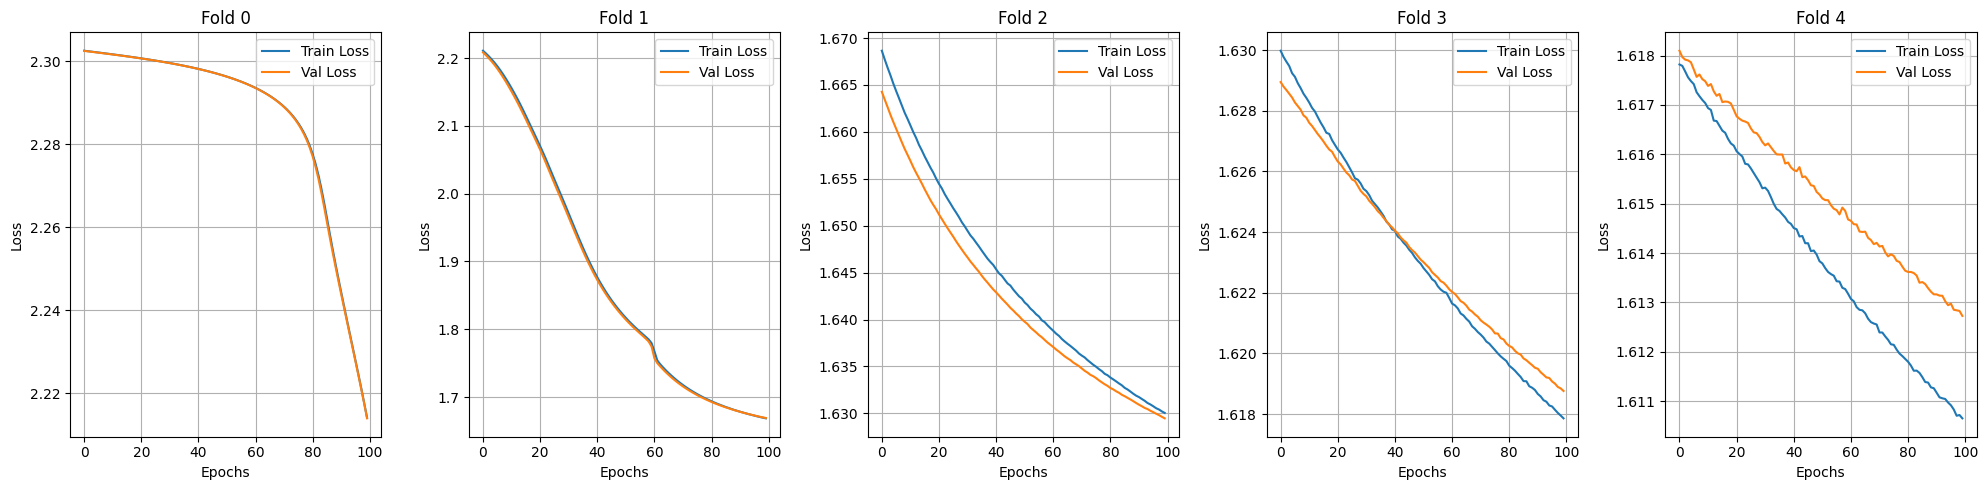

In [99]:
fig,axes = plt.subplots(1,5, figsize=(20,5))

for fold in range(5):
    checkpoint = torch.load(f'best_mlp_{fold}.pth')
    axes[fold].plot(checkpoint['train_losses'], label='Train Loss')
    axes[fold].plot(checkpoint['val_losses'], label='Val Loss')
    axes[fold].set_title(f'Fold {fold}')
    axes[fold].legend()
    axes[fold].set_xlabel('Epochs')
    axes[fold].set_ylabel('Loss')
    axes[fold].grid(True)

plt.tight_layout()
plt.show()

---

# Zadanie 2.

In [7]:
models = []

for fold in range(5):
    checkpoint = torch.load(f'best_mlp_{fold}.pth')
    model = MLP().to('cuda')
    model.load_state_dict(checkpoint['model_state'])
    models.append(model)

---

## Majority Voting

In [ ]:
#Entropia - miara niepewności.
# H(p) = - sum(p_c * log(p_c)) , gdzie:
# p_c - prawdopodonbieństwo klasy c

In [8]:
def majority_vote(models, X_test, y_test):
    test_loader = DataLoader(list(zip(X_test,y_test)), batch_size=1024, shuffle=False)

    all_preds = torch.zeros((len(X_test), len(models)), dtype=torch.int64)

    for idx, model in enumerate(models):
        model.to('cuda')
        model.eval()
        fold_preds = []
        with torch.inference_mode():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to('cuda')
                y_pred = model(X_batch).argmax(dim=1)
                fold_preds.append(y_pred.cpu().numpy())
        all_preds[:, idx] = torch.tensor(np.concatenate(fold_preds))

    print(f"All predictions shape: {all_preds.shape}")

    voting_preds = []

    # Do obliczeń entropii
    n_models = len(models)
    entropies = np.zeros(all_preds.shape[0])

    for i in range(all_preds.shape[0]):
        values, counts = np.unique(all_preds[i], return_counts=True)
        voting_preds.append(values[np.argmax(counts)].item())

        # Obliczanie entropii
        probs = counts / n_models
        entropies[i] = -np.sum(probs * np.log(probs + 1e-10))


    return np.array(voting_preds), np.array(entropies)


In [9]:
preds,entropies = majority_vote(models, X_test, y_test)
preds

c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


All predictions shape: torch.Size([10000, 5])


array([7, 4, 3, ..., 6, 4, 3], shape=(10000,))

In [17]:
pewnosc = 1 - (entropies / entropies.max())

In [21]:
top_indices

array([5848,  391, 6434, 1018, 7482])

In [22]:
preds[top_indices]

array([3, 2, 9, 2, 2])

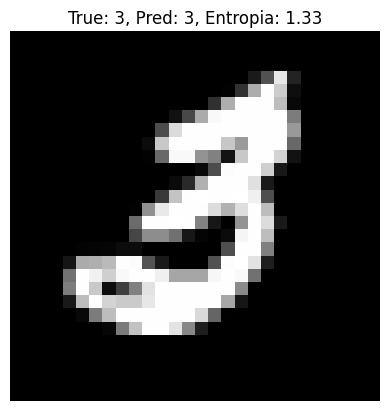

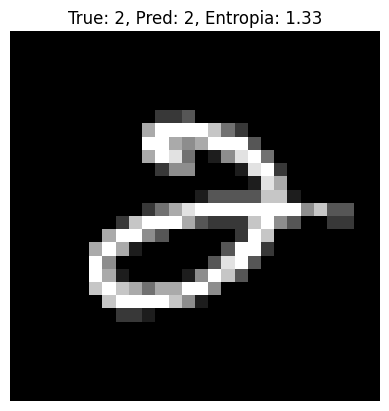

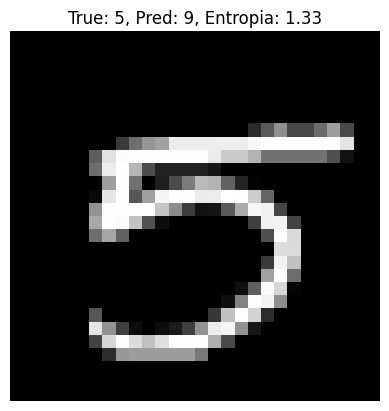

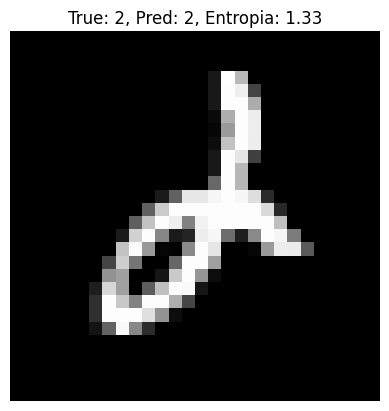

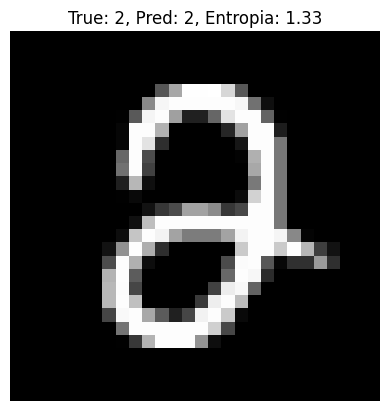

In [20]:
top_indices = np.argsort(entropies)[-5:]
for idx in top_indices:
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {preds[idx]}, Entropia: {entropies[idx]:.2f}")
    plt.axis('off')
    plt.show()

In [10]:
top_indices

NameError: name 'top_indices' is not defined

---

## Mean Response

In [23]:
def mean_response(models, X_test,y_test):
    test_loader = DataLoader(list(zip(X_test,y_test)), batch_size=1024, shuffle=False)

    all_preds = torch.zeros((len(X_test), len(models), 10), dtype=torch.float32)

    for idx, model in enumerate(models):
        model.to('cuda')
        model.eval()
        fold_preds = []
        with torch.inference_mode():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to('cuda')
                y_pred = model(X_batch)
                fold_preds.append(y_pred.cpu().numpy())
        all_preds[:, idx, :] = torch.tensor(np.concatenate(fold_preds))

    print(f"All predictions shape: {all_preds.shape}")

    mean_preds = np.mean(all_preds.numpy(), axis=1)
    final_preds = np.argmax(mean_preds, axis=1)

    entropies = -np.sum(mean_preds * np.log(mean_preds + 1e-10), axis=1)

    return final_preds, entropies


In [14]:
mean_preds, mean_entropies = mean_response(models, X_test, y_test)
mean_preds

NameError: name 'mean_response' is not defined

In [13]:
top_indices = np.argsort(mean_entropies)[-5:]
for idx in top_indices:
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {preds[idx]}, Entropia: {mean_entropies[idx]:.4f}")
    plt.axis('off')
    plt.show()

NameError: name 'mean_entropies' is not defined

In [12]:
top_indices

NameError: name 'top_indices' is not defined

---

In [37]:
def calc_accuracy(preds, y_true):
    return np.mean(preds == y_true)

In [39]:
voting_acc = calc_accuracy(preds, y_test)
mean_acc = calc_accuracy(mean_preds, y_test)

print(f"Voting Accuracy: {voting_acc:.4f} | Mean Response Accuracy: {mean_acc:.4f}")

Voting Accuracy: 0.8432 | Mean Response Accuracy: 0.8446


In [52]:
def QCochran(y_true, preds_list):
    k = len(preds_list)  # liczba metod

    binary_preds = np.array([(preds == y_true).astype(int) for preds in preds_list])

    G = np.sum(binary_preds, axis=0) # suma poprawnych predyckcji dla każdej metody
    L = np.sum(binary_preds, axis=1) # suma poprawnych predykcjki dla każdego obrazka

    T = np.sum(G)
    R = np.sum(G**2)
    C = np.sum(L**2)

    Q = ((k - 1) * (k * C - T**2)) / (k * T - R)

    # p-value 
    df = k - 1
    p_value = stats.chi2.sf(Q, df)

    return Q, p_value

In [53]:
Q, p_value = QCochran(y_test, [preds, mean_preds])
print(f"Q: {Q:.4f} | p-value: {p_value:.4f}")

Q: 3.3793 | p-value: 0.0660


In [ ]:
# Nie wiem.

---

# Zadanie 3: Dobrór Learning Rate

In [56]:
import optuna
from tqdm import tqdm

from sklearn.model_selection import cross_val_score

In [ ]:
def find_best_lr(train_loader, val_loader):
    def objective(trial:optuna.Trial):
        lr = trial.suggest_float('lr', 1e-5, 0.1, log=True)

        model = MLP().to('cuda')
        optimizer = optim.SGD(params=model.parameters(),lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        for epoch in range(10):
            model.train()
            train_loss = 0.0

            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
                
                optimizer.zero_grad()
                y_pred = model(X_batch)

                loss = loss_fn(y_pred, y_batch)

                loss.backward()
                optimizer.step()
                train_loss += loss.item()

        score = cross_val_score(
            model, X_trainval, y_trainval, cv=5, scoring='accuracy'
        )

        return score.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    return study.best_params['lr']



---

# Zadanie 4. Porównanie Optymalizatorów